In [ ]:
import numpy as np
import os

import sys
sys.path.append('/mnt/e/fyassine/ad-early-detection')
import config

from model.data_understanding.statistical_tests._artifacts.edges_utils import run_network_analysis, run_diagnostic_tests
from import_utils import load_and_process_cohorts

In [2]:
cohorts = load_and_process_cohorts(config, correlation_type="pearson", remove_nan=True)
print('\n' + str(cohorts.keys()))

Healthy: 201 subjects, Matrix shape: (201, 110, 110), Edges shape: (201, 5995)
AD: 104 subjects, Matrix shape: (104, 110, 110), Edges shape: (104, 5995)
MCI: 533 subjects, Matrix shape: (533, 110, 110), Edges shape: (533, 5995)
Converters: 60 subjects, Matrix shape: (60, 110, 110), Edges shape: (60, 5995)

dict_keys(['healthy', 'ad', 'mci', 'converter'])


In [3]:
converters = cohorts['converter']
non_converters = {
    'name': 'Non-Converters',
    'ids': np.concatenate([cohorts['healthy']['ids'], cohorts['mci']['ids']]),
    'matrices': np.vstack([cohorts['healthy']['matrices'], cohorts['mci']['matrices']]),
    'edges': np.vstack([cohorts['healthy']['edges'], cohorts['mci']['edges']])
}
print('\n' + str(converters.keys()))
print(str(non_converters.keys()))

conv_edges, conv_ids = converters['edges'], converters['ids']
non_conv_edges, non_conv_ids = non_converters['edges'], non_converters['ids']

cohorts = {
    "converters": {
        "name": "Converters",
        "ids": conv_ids, 
        "edges": conv_edges
    },
    "non_converters": {
        "name": "Non Converters",
        "ids": non_conv_ids,
        "edges": non_conv_edges
    }
}


dict_keys(['name', 'ids', 'matrices', 'edges'])
dict_keys(['name', 'ids', 'matrices', 'edges'])


In [4]:
run_network_analysis(
    cohorts, 
    group_a="converters", 
    group_b="non_converters", 
    nbs_threshold=3.0, 
    n_perms=5000,
    run_permanova=True,
    run_nbs=True
)

{'permanova': {'f_statistic': np.float64(1.7874082833204443),
  'r_squared': np.float64(0.0022517468338102923),
  'p_value': np.float64(0.0),
  'null_distribution': array([1.03124782, 0.86535212, 0.80830032, ..., 1.18665444, 1.25683331,
         0.93901725], shape=(5000,)),
  'distance_metric': 'euclidean'},
 'nbs': {'test_statistics': array([-0.9113658 ,  0.12474737, -0.89792051, ...,  0.66851523,
          1.39274841,  2.54517016], shape=(5995,)),
  'suprathreshold_edges': array([False, False, False, ..., False, False, False], shape=(5995,)),
  'all_components': [{'edges': array([ 234,  238,  252,  261,  291,  301,  307,  312,  358,  447,  501,
            538,  539,  548,  549,  553,  560,  565,  576,  591,  631,  679,
            734,  766,  811,  821,  827,  832,  850,  995, 1066, 1094, 1170,
           1225, 1226, 1264, 1288, 1305, 1322, 1367, 1388, 1393, 1422, 1458,
           1577, 1659, 1705, 1742, 1844, 1940, 1971, 2001, 2073, 2177, 2179,
           2347, 2402, 2432, 2437, 24

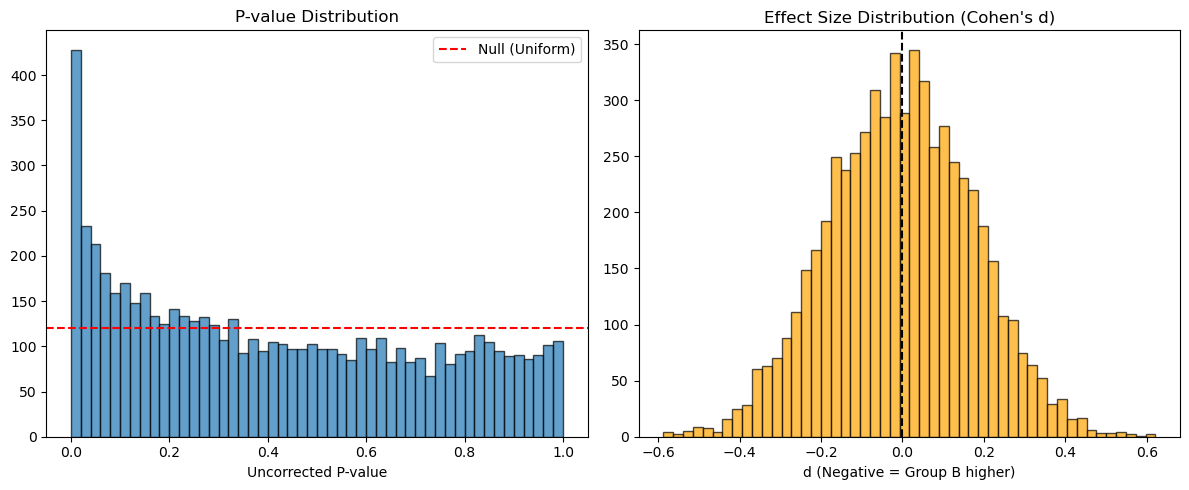

{'valid': True,
 'pair_name': 'Converters vs Non Converters',
 'n_a': 60,
 'n_b': 734,
 'min_sample_size': 60,
 'avg_sd_a': np.float64(0.17679839384439308),
 'avg_sd_b': np.float64(0.17898672579759736),
 'sig_uncorrected': np.int64(767),
 'sig_fdr_count': np.int64(16),
 'sig_fdr_pct': np.float64(0.26688907422852376),
 'median_effect_size': np.float64(0.12296042454327596),
 'pct_medium_effect': np.float64(0.48373644703919927),
 'pct_large_effect': np.float64(0.0),
 'pvals': array([0.55844777, 0.66676497, 0.47236937, ..., 0.36093692, 0.22166647,
        0.04259331], shape=(5995,)),
 'pvals_fdr': array([0.85253232, 0.89742175, 0.80910125, ..., 0.73374597, 0.63190227,
        0.36477254], shape=(5995,)),
 'cohens_d': array([-0.12596459,  0.0166743 , -0.12250642, ...,  0.09325734,
         0.18541801,  0.32307184], shape=(5995,))}

In [5]:
run_diagnostic_tests(cohorts, group_a="converters", group_b="non_converters")